# README


**Project Title:**  

**Tutorial section: TT6L**

**Group04**

<div align="left">
    
| | Student ID     | Student Name                | Contribution | 
|--:|:-------------|:----------------------------|-------------:|
| 1 | Student_ID1  | Student_Name1               | 30%          | 
| 2 | Student_ID2  | Student_Name1               | 20%          | 
| 3 | Student_ID3  | Student_Name1               | 10%          | 
| 4 | Student_ID4  | Student_Name1               | 40%          | 

</div>

Note: Marks may vary among group members based on individual contributions. Ensure all members agree on the contribution percentages listed here.

**YouTube link:**  
Please note that the examiner will not notify you if your video link is unavailable, inaccessible, or incorrectly provided. It is the responsibility of the group to ensure that the video link is fully functional and accessible at the time of assessment. Failure to provide a valid and working link will result in a score of zero (0) marks for the presentation component.

**Dataset Title:**  
**Source & Link:** (e.g., Kaggle / UCI / Data.gov / Google Dataset Search — provide the dataset page URL)  
**Download instructions:** If the dataset requires sign-in (e.g., Kaggle), document the exact steps here      
**Brief Description (2–4 sentences):**   

**How to Run (if required, 1–3 steps):**  
  Instructions to run the notebook, including how to place the dataset files.    
  

## 1. Introduction & Problem Statement
- What is the main objective of this analysis?
- What key questions/hypotheses will you explore?
- Why is this dataset suitable for these questions?
- All citations must be in listed in APA style.


In [1]:
import numpy as np
import pandas as pd
from numpy import nan as NA
import matplotlib.pyplot as plt
%matplotlib inline

## 2. Data Source & Understanding
- **Description:** Features/columns, size, time span, units
- **Limitations:** Coverage, missingness, sampling bias, known caveats


## 3. Initial Data Checks
- Shape, columns, dtypes
- Sample rows (head/tail)
- Basic summary statistics


In [2]:
netflix = pd.read_csv('netflix_titles.csv')
netflix.shape

(8807, 12)

In [3]:
netflix.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [4]:
netflix.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

## 4. Data Cleaning & Preprocessing
- Handle missing values (strategy and justification)
- Fix types (dates, categoricals, numerics)
- Remove/flag outliers
- Feature engineering (document purpose)
- Keep transformations transparent and reproducible


### Data Cleaning

In [5]:
netflix = pd.read_csv('netflix_titles.csv')
print(netflix.shape)
netflix.head()

(8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


#### Handle missing data

In [6]:
null_rows = netflix.isnull().any(axis=1)
netflix[null_rows] #shows 3475 rows with missing data


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8795,s8796,TV Show,Yu-Gi-Oh! Arc-V,NaN,"Mike Liscio, Emily Bauer, Billy Bob Thompson, ...","Japan, Canada","May 1, 2018",2015,TV-Y7,2 Seasons,"Anime Series, Kids' TV",Now that he's discovered the Pendulum Summonin...
8796,s8797,TV Show,Yunus Emre,NaN,"Gökhan Atalay, Payidar Tüfekçioglu, Baran Akbu...",Turkey,"January 17, 2017",2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas","During the Mongol invasions, Yunus Emre leaves..."
8797,s8798,TV Show,Zak Storm,NaN,"Michael Johnston, Jessica Gee-George, Christin...","United States, France, South Korea, Indonesia","September 13, 2018",2016,TV-Y7,3 Seasons,Kids' TV,Teen surfer Zak Storm is mysteriously transpor...
8800,s8801,TV Show,Zindagi Gulzar Hai,NaN,"Sanam Saeed, Fawad Khan, Ayesha Omer, Mehreen ...",Pakistan,"December 15, 2016",2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...","Strong-willed, middle-class Kashaf and carefre..."


In [7]:
netflix[null_rows].shape

(3475, 12)

In [8]:
netflix.isnull().sum() #check null value total

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [9]:
def null_values(netflix):
    
    #Fill director, cast and country with null value with 'Unknown'
    netflix['director'] = netflix['director'].fillna('Unknown')
    netflix['cast'] = netflix['cast'].fillna('Unknown')
    netflix['country'] = netflix['country'].fillna('Unknown')

    #Drop null value of date_added and duration
    netflix = netflix.dropna(subset = ['date_added'])
    netflix = netflix.dropna(subset = ['duration'])

    #Replace rating with most frequent category
    netflix["rating"] =  netflix["rating"].fillna(netflix["rating"].mode()[0]) 

    return netflix

#### Check on Data Type

In [10]:
netflix.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

In [11]:
def fix_datatypes(netflix):
    #Convert 'date_added' to datetime instead of string
    netflix['date_added'] = netflix['date_added'].str.strip() # to clean the extra spaces
    netflix['date_added'] = pd.to_datetime(netflix['date_added'])

    return netflix

#### Check Duplicated Data

In [12]:
netflix.duplicated().sum()

np.int64(0)

#### Clean Text

In [13]:
def clean_text(netflix):

    netflix['type'] = netflix['type'].str.strip().str.upper()
    
    #Only one country per show
    netflix['country'] = netflix['country'].str.split(',').str[0]

    return netflix

#### Divide Duration into it type and value

In [14]:
def divide_duration(netflix):

    #Divide duration into type and value
    netflix[['duration_value', 'duration_type']] = netflix['duration'].str.split(' ', n=1, expand=True)
    netflix['duration_value'] = netflix['duration_value'].astype(int)

    return netflix

### Create Cleaning Pipepline

In [15]:
clean_netflix = (
    netflix
    .pipe(null_values)
    .pipe(fix_datatypes)
    .pipe(clean_text)
    .pipe(divide_duration)

)

In [16]:

clean_netflix.to_csv('netflix_cleaned.csv', index = False)

## 5. Exploratory Data Analysis (EDA)
- Univariate distributions
- Bivariate relationships
- Correlations/associations
- Well-labeled, readable plots with units where applicable


## Univariate Distributions

### Content Type Distribution: Number of Movies vs TV Shows

Text(0.5, 1.0, 'Distribution of Content Type')

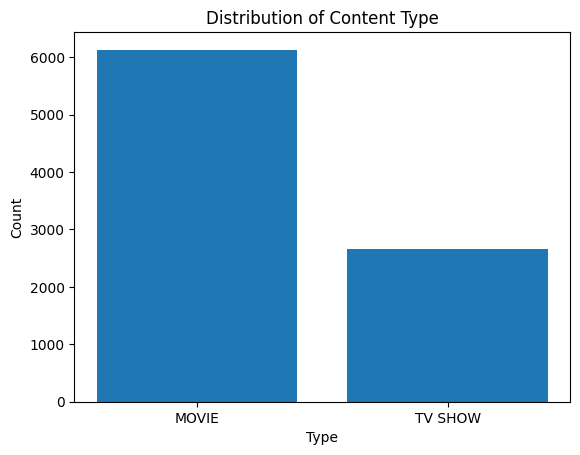

In [17]:
movie_type = ["MOVIE", "TV SHOW"]

netflix_cleaned = pd.read_csv('netflix_cleaned.csv')
plt.bar(movie_type, netflix_cleaned["type"].value_counts())

# set x/y labels and plot title
plt.xlabel("Type")
plt.ylabel("Count")
plt.title("Distribution of Content Type")

### Release Year Distribution: How many titles were released each year

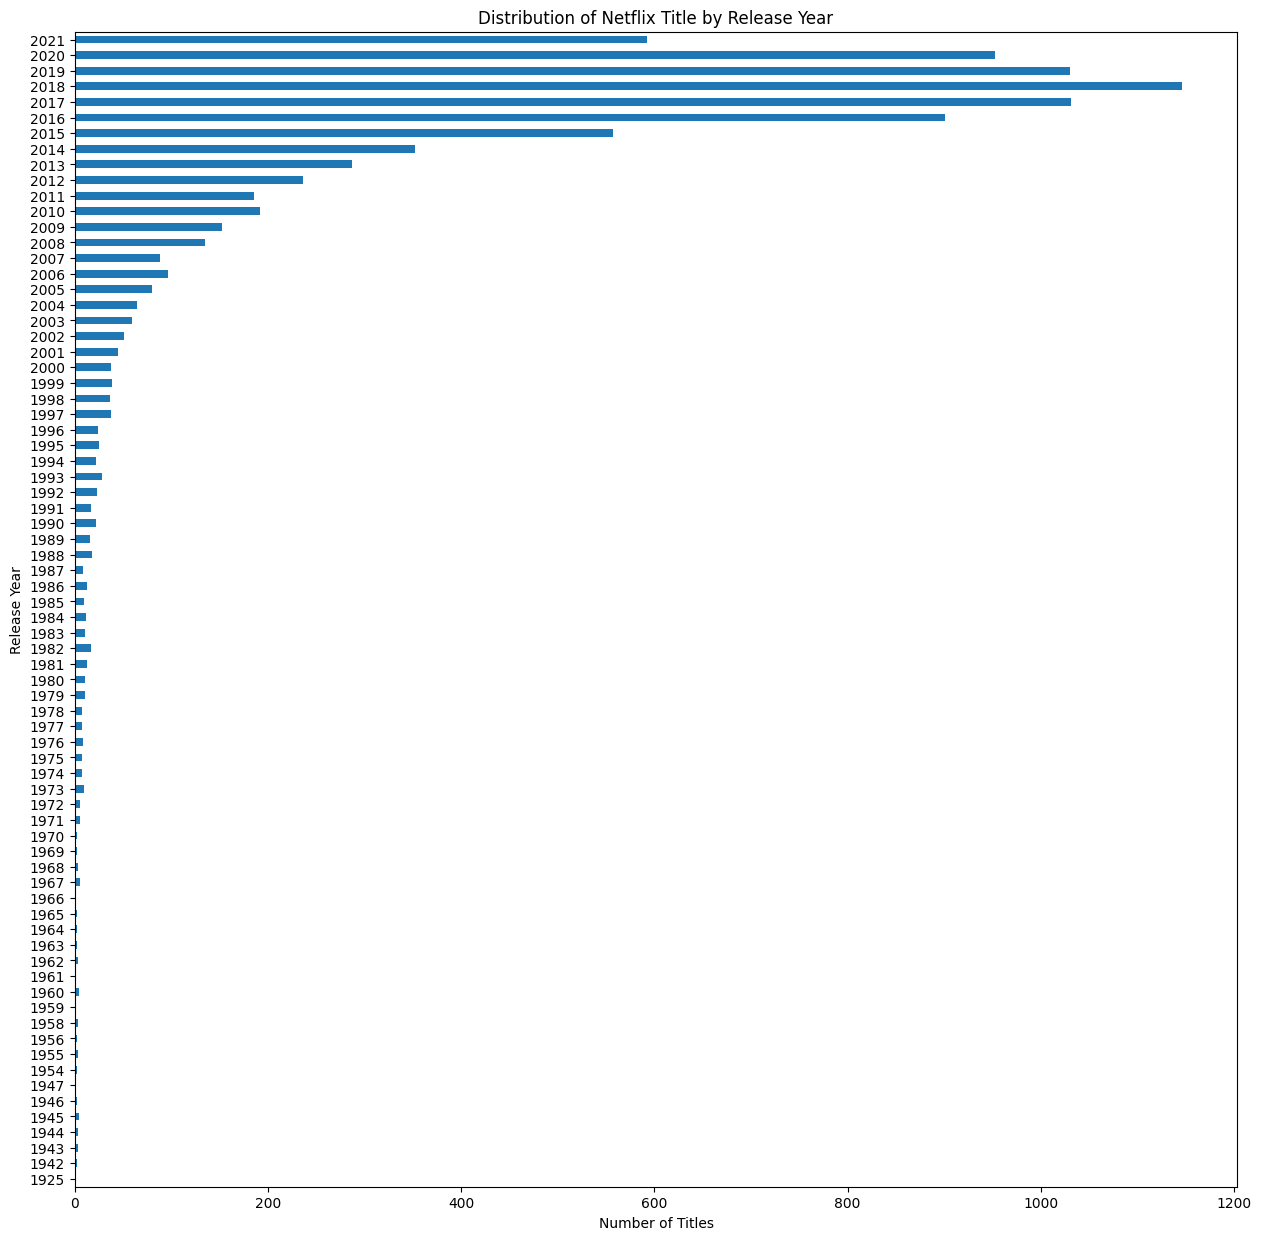

In [18]:
release_year_dist = netflix_cleaned['release_year'].value_counts().sort_index()
release_year_dist.plot(
    kind='barh',
    figsize=(15,15)
)

plt.title('Distribution of Netflix Title by Release Year')
plt.xlabel('Number of Titles')
plt.ylabel('Release Year')
plt.show()


### Country Distribution: Top countries producing content

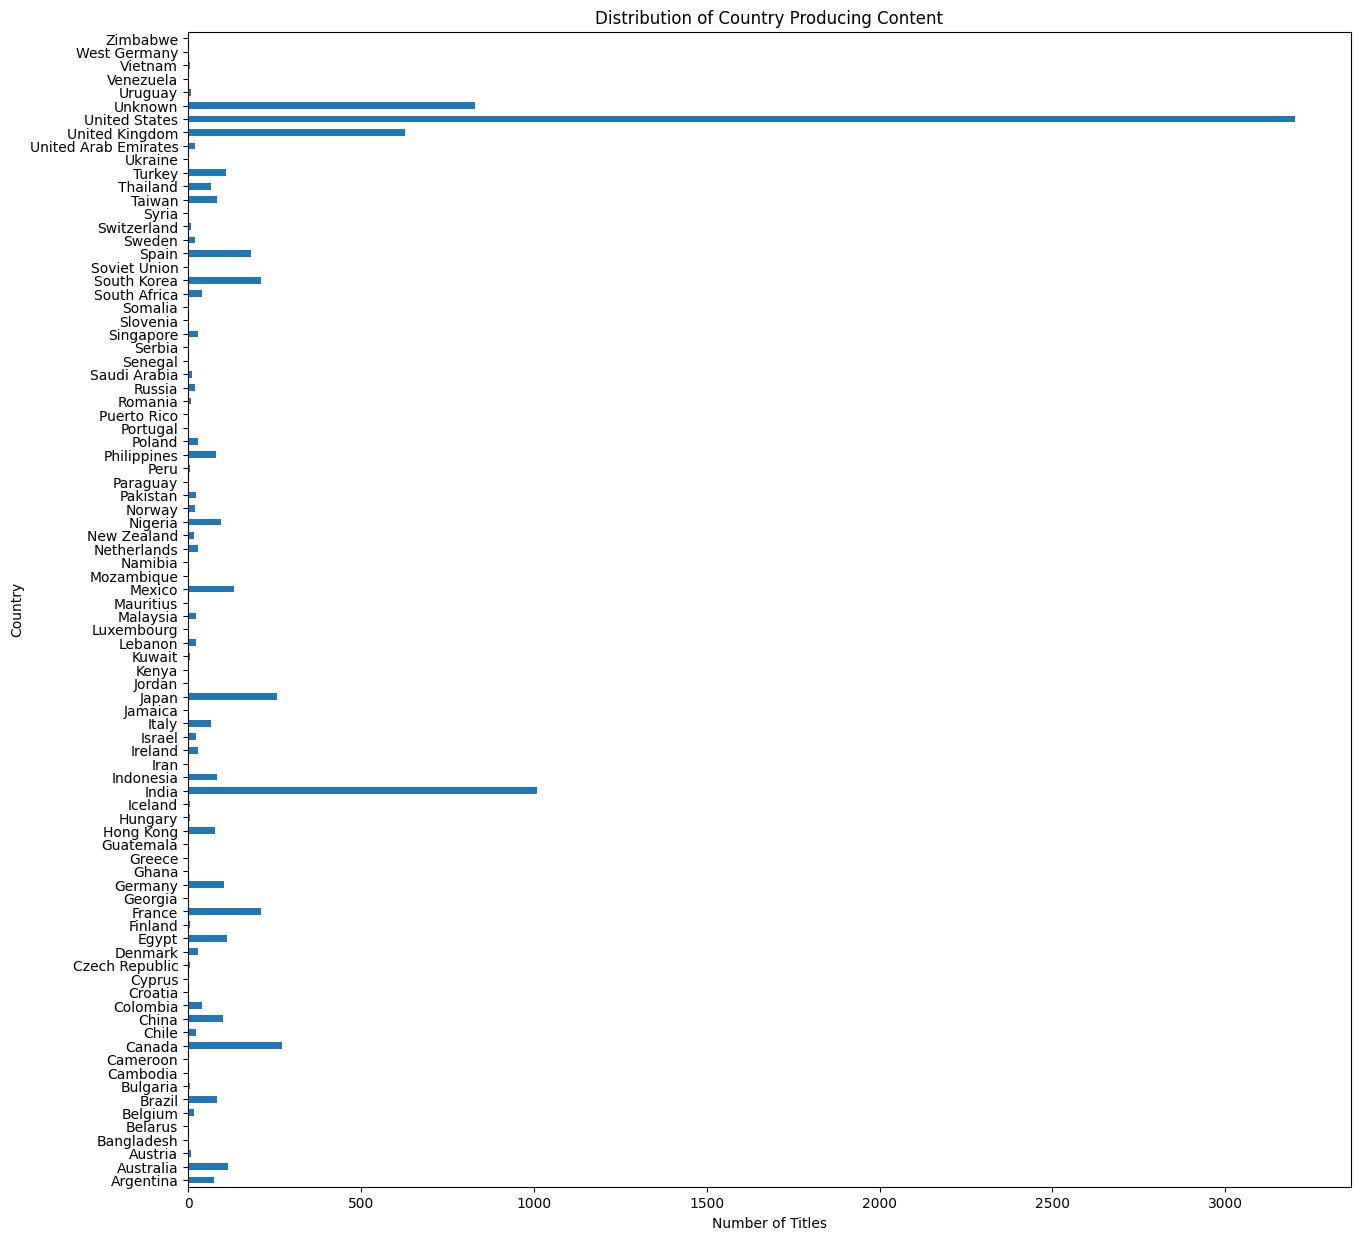

In [19]:
country_dist = netflix_cleaned['country'].value_counts().sort_index()
country_dist.plot(
    kind='barh',
    figsize=(15,15)
)

plt.title('Distribution of Country Producing Content')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

## Bivariate Relationship

### Country vs Type : Which countries produce more movies or TV shows?

<function matplotlib.pyplot.show(close=None, block=None)>

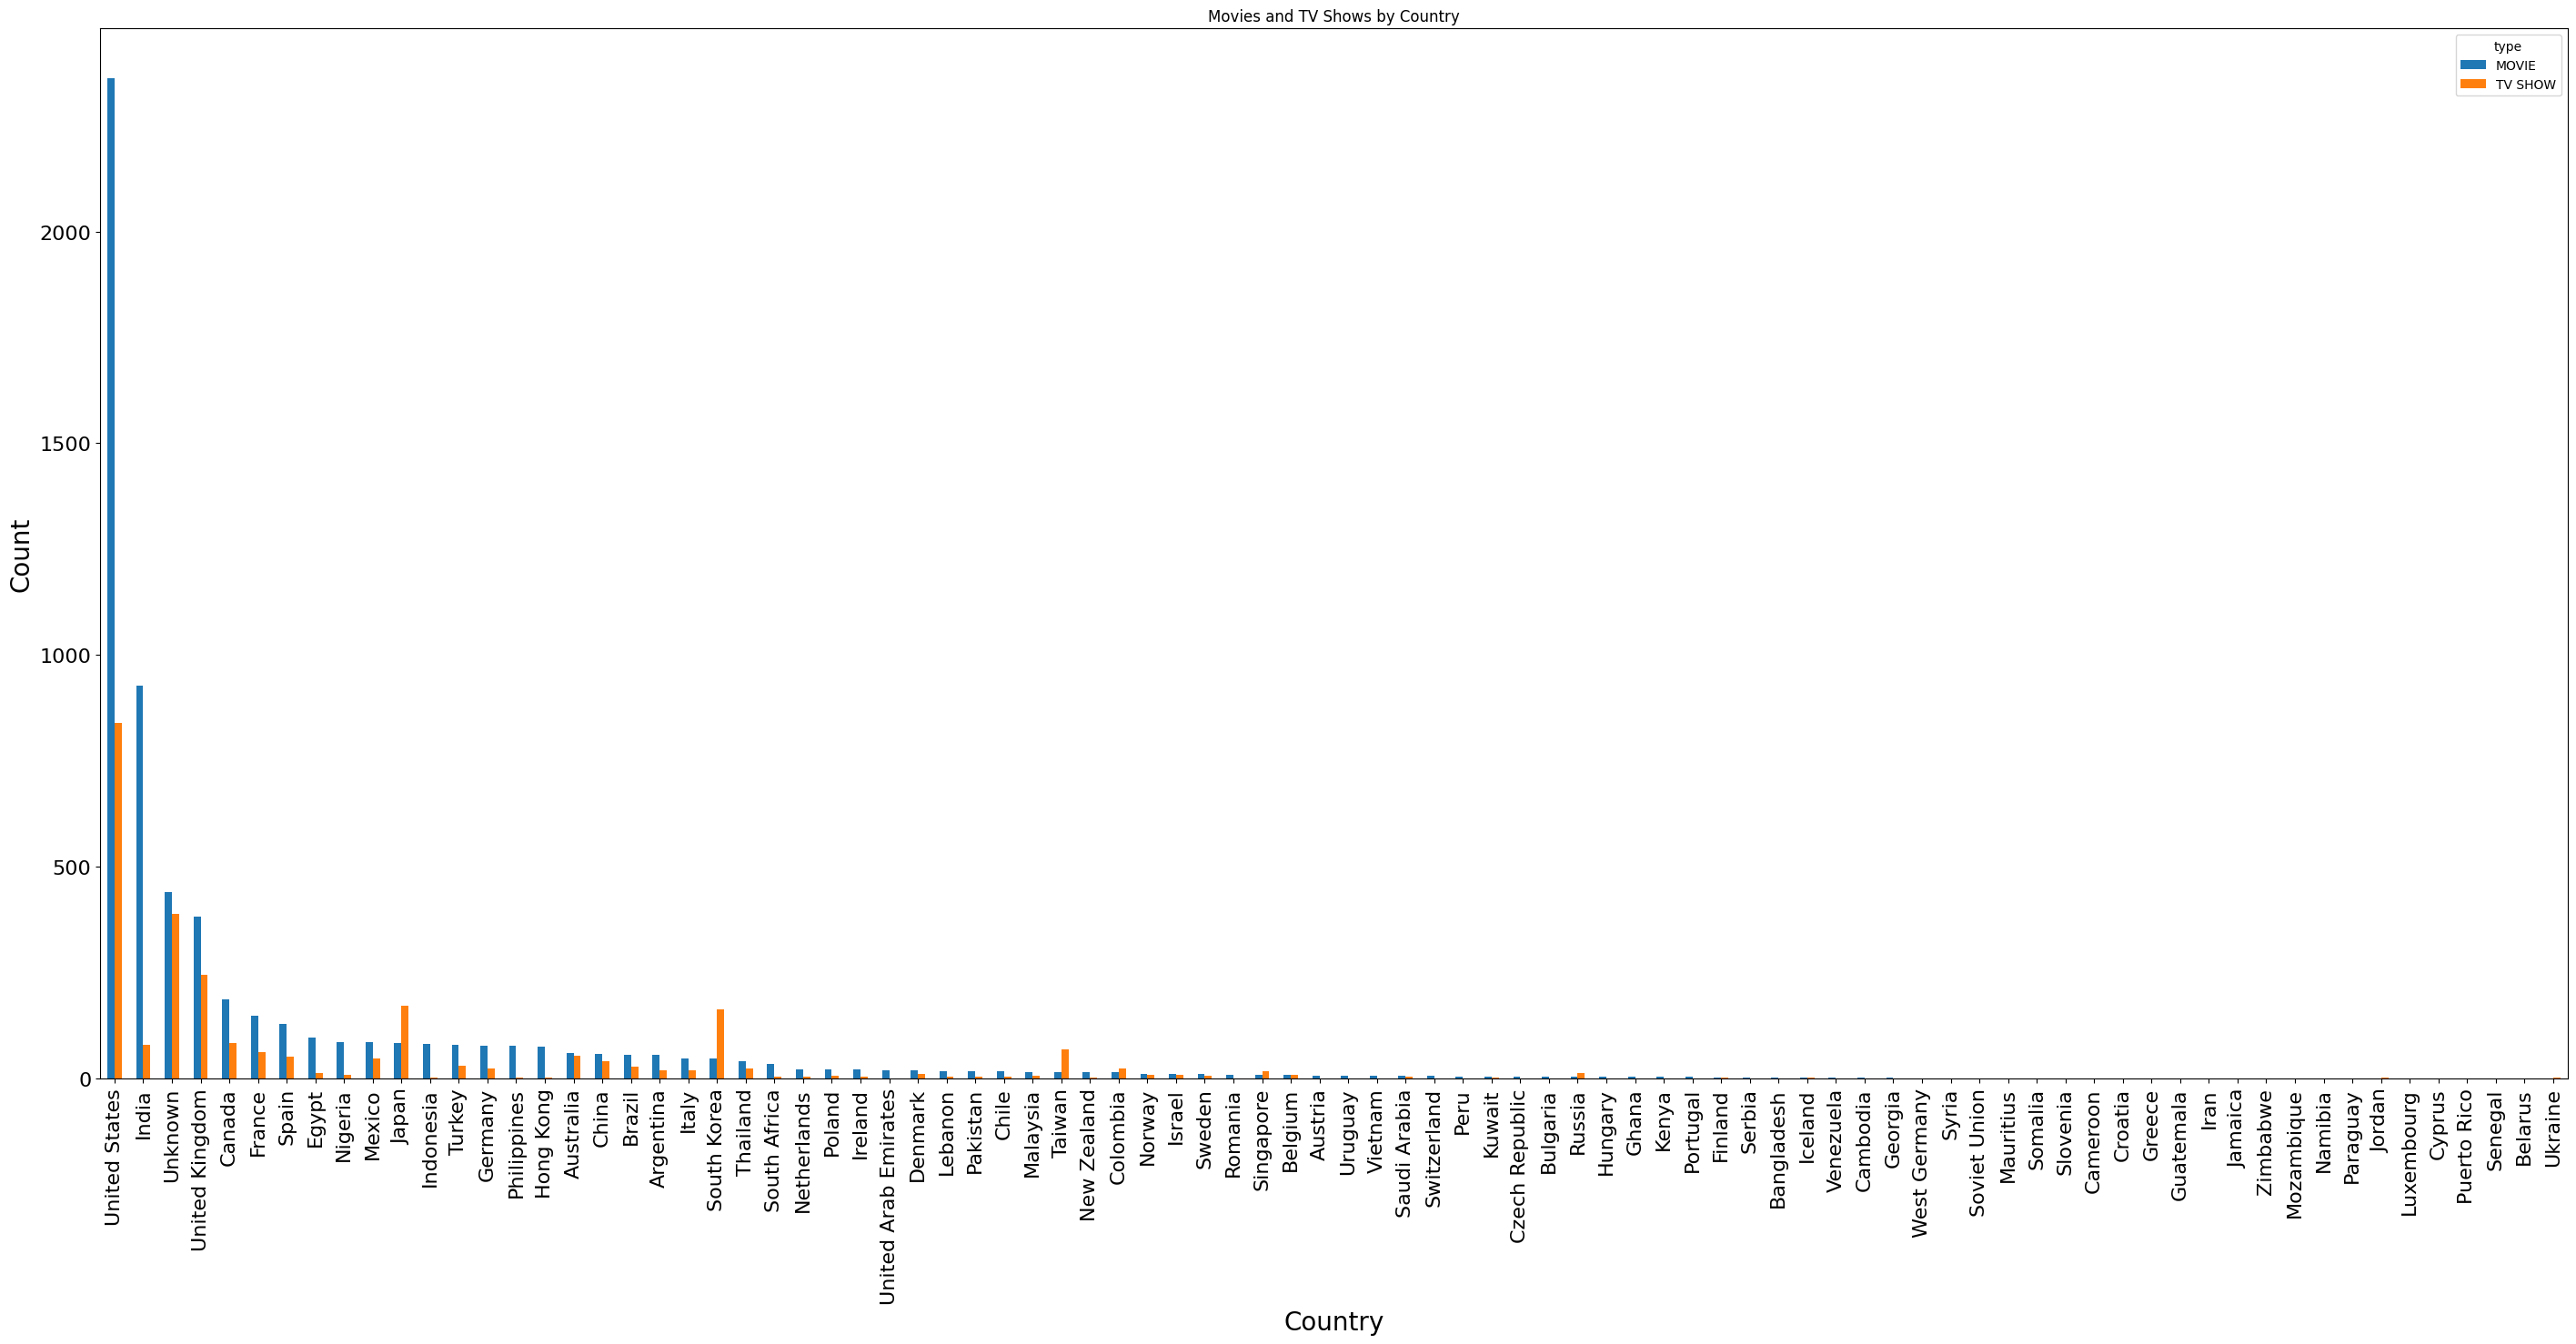

In [46]:
country_type = (netflix_cleaned.groupby(['country', 'type'])
                .size()
                .unstack(fill_value=0)
                )

# find countries with most movies
country_type.sort_values('MOVIE', ascending=False)

# find countries with most TV shows
country_type.sort_values('TV SHOW', ascending=False)

country_type.sort_values('MOVIE', ascending=False).plot(
    kind='bar',
    figsize=(35,15),
)

plt.title('Movies and TV Shows by Country')
plt.ylabel('Count', fontsize=20)
plt.xlabel('Country', fontsize=20)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.show


## Measures of Central Tendency

In [49]:
# Mean
netflix_cleaned['release_year'].mean()

# Mode
netflix_cleaned['released_year'].mode()


KeyError: 'released_year'

## 6. Modeling / Deeper Analysis (if applicable)
- Define task (prediction, classification, clustering, inference, etc.)
- Train/test split or cross-validation
- Baselines, metrics, and parameter choices
- Control randomness with fixed seeds


## 7. Performance Evaluation and Enhancement (if applicable)

## 8. The FOUR Analytical Questions
- Answer each questions with supporting facts from the data analysis.
- Use visuals for clearer communication whenever possible. 


### Classification
Can we classify whether a Netflix title is a Movie or TV show based on duration, genre, rating and release year?


#### Section 1: Import libraries and Load Data 

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier


%matplotlib inline

# Load cleaned Netflix dataset 
df = pd.read_csv('netflix_cleaned.csv')

# Display the first few rows
display(df.head())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_value,duration_type
0,s1,MOVIE,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,min
1,s2,TV SHOW,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2,Seasons
2,s3,TV SHOW,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1,Season
3,s4,TV SHOW,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1,Season
4,s5,TV SHOW,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2,Seasons


First, we load the cleaned dataset and import related libraries. 

#### Section 2: Data Cleaning & Feature Selection

In [ ]:
# Selected features.
columns_to_keep = ['type', 'release_year', 'rating', 'listed_in']
df = df[columns_to_keep].dropna()

# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Check for duplicated rows
print("\nDuplicated rows:", df.duplicated().sum())

# Drop duplicates 
df.drop_duplicates(inplace=True)
display(df.info())

Missing values:
 type            0
release_year    0
rating          0
listed_in       0
dtype: int64

Duplicated rows: 4480
<class 'pandas.core.frame.DataFrame'>
Index: 4314 entries, 0 to 8791
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          4314 non-null   object
 1   release_year  4314 non-null   int64 
 2   rating        4314 non-null   object
 3   listed_in     4314 non-null   object
dtypes: int64(1), object(3)
memory usage: 168.5+ KB


None

Even though the dataset is already cleaned, we need to make sure that there is no missing values and duplicated rows, to make sure that the data we give to the learning models is not corrupted. 

As you can see in the columns_to_keep variable, the 'duration' column is missing, the reason this column was discarded is to prevent data leaking. The 'duration' column's data entry for Movies are 'mins' and TV shows are 'seasons'. With this kind of information being fed to the models, it will achieve a perfect score, making it unreliable. As such, the 'duration' column was discarded.

#### Section 3: EDA

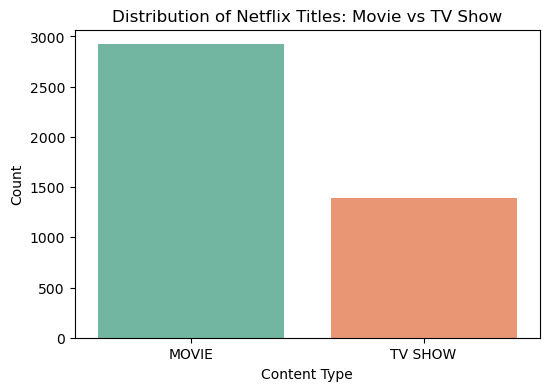

type
MOVIE      2921
TV SHOW    1393
Name: count, dtype: int64


In [ ]:
# Plot the distribution of the target variable ('type')
plt.figure(figsize=(6, 4))
sns.countplot(x='type', data=df, hue='type', palette='Set2', legend=False)
plt.title('Distribution of Netflix Titles: Movie vs TV Show')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()

# Print exact count
print(df['type'].value_counts())

The total count of both Movies and TV Shows are 2921 and 1393 respectively, making a grand total of 4314.

#### Section 4: Data Preprocessing

In [ ]:
# Encode Target Variable: 'MOVIE' = 0, 'TV SHOW' = 1
df['type_encoded'] = df['type'].map({'MOVIE': 0, 'TV SHOW': 1})

# Encode the 'rating' column
rating_dummies = pd.get_dummies(df['rating'], prefix='rating')

# Fixing Leakage
# Must remove the words "TV" and "Movies" etc. from genre text so the model 
# has to actually learn the underlying patterns
df['clean_genres'] = df['listed_in'].str.replace('TV ', '', regex=False)\
                                    .str.replace(' Movies', '', regex=False)\
                                    .str.replace('Movies', '', regex=False)\
                                    .str.replace(' Shows', '', regex=False)

# Encode the sanitized genres
genre_dummies = df['clean_genres'].str.get_dummies(sep=', ')

# Create X and y DataFrames
X = pd.concat([df[['release_year']], rating_dummies, genre_dummies], axis=1)
y = df['type_encoded']

print("Sanitized Features shape:", X.shape)

Sanitized Features shape: (4314, 48)


**Data Preprocessing**

Data preprocessing is a step where we transform our raw data into a format the algorithm can process. For this dataset, we chose to use **One-Hot Encoding** to convert categorical text columns such as 'rating' and 'listed_in' into binary columns containing '0's and '1's.

**Data Leakage**

After runnning an initial test, we found another severe case of data leakage, which resulted in an accuracy of 99.9%. We found that in the 'listed_in' column, many genres explicitly contained our target labels within their names, (e.g., "Kids' **TV**, Horror **Movies**)

To address this issue, we introduced a sanitization step. Before one-hot encoding the genres, we used string manipulation to strip the words "TV", "Shows", and "Movies" entirely out of the dataset. This forces our model to instead learn the bahavioral patterns.

#### Section 5: Split the Data

In [ ]:
# Split the data into training and testing sets (70%-30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (3019, 48)
Testing set size: (1295, 48)


We divide our dataset into a Training Set (70%) for the model to learn from, and a Testing Set (30%) to evaluate its performance.

This is done to avoid **Overfitting**. Which is an error caused by the model simply memorizing the data, rathen than learning patterns. 

**Code Breakdown:**
* `test_size=0.30`: Reserves exactly 30% of the data for the final evaluation.
* `random_state=42`: Locks the random seed. This ensures the data splits the exact same way every time the cell is run, keeping our data science pipeline **100% reproducible**.

#### Section 6: Train Classifiers

In [ ]:
# Train Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Train Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# Train Decision Tree
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Here, we feed our 70% training data (`X_train` and `y_train`) into three distinct machine learning algorithms so they can learn the rules of what makes a Netflix title a Movie versus a TV Show.

By training models from different statistical families, we can compare their performance and find the best fit for our specific problem.

* **Logistic Regression:** It calculates probabilities using linear equations.
* **Decision Tree:** A rule-based model that asks a series of Yes/No questions to split the data. It is highly interpretable but prone to overfitting (memorizing the training data).
* **Random Forest:** An "ensemble" method. It builds 100 different Decision Trees and takes a majority vote to make a final prediction. This solves the overfitting problem of a single tree and is exceptionally good at handling complex categorical data like our genres.

**Code Breakdown:**
* `model = ...`: Initializes the algorithm with our chosen settings.
* `.fit(X_train, y_train)`: The algorithm analyzes the features (`X_train`) to calculate how they map to the correct target labels (`y_train`).

#### Section 7: Evaluate Models and Visualise Confusion Matrix

=== Logistic Regression Results ===
Accuracy: 0.9204633204633205

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94       858
           1       0.99      0.77      0.87       437

    accuracy                           0.92      1295
   macro avg       0.94      0.88      0.91      1295
weighted avg       0.93      0.92      0.92      1295



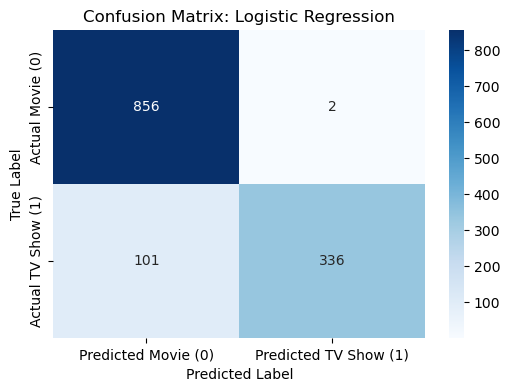


=== Random Forest Results ===
Accuracy: 0.8903474903474904

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.93      0.92       858
           1       0.86      0.81      0.83       437

    accuracy                           0.89      1295
   macro avg       0.88      0.87      0.88      1295
weighted avg       0.89      0.89      0.89      1295



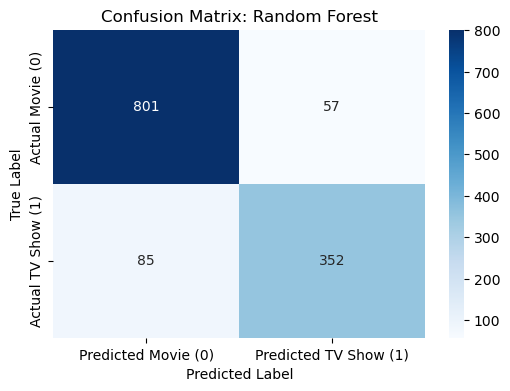


=== Decision Tree Results ===
Accuracy: 0.8872586872586873

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.92       858
           1       0.84      0.82      0.83       437

    accuracy                           0.89      1295
   macro avg       0.88      0.87      0.87      1295
weighted avg       0.89      0.89      0.89      1295



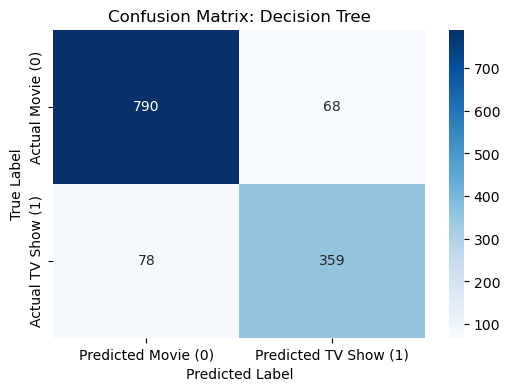

In [ ]:
# Evaluate Logistic Regression 
y_pred_log = log_reg.predict(X_test)
print("=== Logistic Regression Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

# Visualize Confusion Matrix for Logistic Regression 
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Movie (0)', 'Predicted TV Show (1)'],
            yticklabels=['Actual Movie (0)', 'Actual TV Show (1)'])
plt.title('Confusion Matrix: Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Evaluate Random Forest
y_pred_rf = rf_clf.predict(X_test)
print("\n=== Random Forest Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Visualize Confusion Matrix for Random Forest
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Movie (0)', 'Predicted TV Show (1)'],
            yticklabels=['Actual Movie (0)', 'Actual TV Show (1)'])
plt.title('Confusion Matrix: Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Evaluate Decision Tree 
y_pred_dt = dt_clf.predict(X_test)
print("\n=== Decision Tree Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

# Visualize Confusion Matrix for Decision Tree 
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Movie (0)', 'Predicted TV Show (1)'],
            yticklabels=['Actual Movie (0)', 'Actual TV Show (1)'])
plt.title('Confusion Matrix: Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

After training and evaluating three distinct classification models, we achieved strong, realistic predictive performance. **Logistic Regression** emerged as the most accurate model overall, achieving **92.0% accuracy**, outperforming both the Random Forest (89.0%) and the Decision Tree (88.7%). 

However, by analyzing the Classification Reports, we uncovered several crucial insights about our Netflix data:

**1. Class Imbalance Effect**
By looking at the `support` column: there are 858 Movies but only 437 TV Shows in our test set. Because there are almost twice as many movies, the Logistic Regression model became heavily biased toward guessing "Movie". 
* It achieved a perfect **Recall of 1.00** for Movies, meaning it found 100% of the movies.
* But its Recall for TV Shows dropped to **0.77** (meaning it missed 23% of the TV shows, incorrectly labeling them as Movies). 

**2. Precision vs. Recall Trade-off**
While Logistic Regression missed some TV shows, when it *did* predict a TV Show, it was almost never wrong (Precision of **0.99**). 
The Random Forest and Decision Tree models were slightly more "balanced" in how they treated both classes, but they made more overall mistakes, bringing their total accuracy down to 89%. 

**3. Tree vs. Forest**
As expected, the Random Forest (89.0%) slightly outperformed the single Decision Tree (88.7%). This proves the theory that a group of 100 trees voting together is more robust than a single tree, which is prone to memorizing the training data.

**Conclusion**
Can we predict if a Netflix title is a Movie or a TV Show based strictly on its release year, age rating, and sanitized genres? **Yes.** With 92% accuracy, Logistic Regression proves that there are strong, mathematically distinct patterns in how Netflix categorizes, rates, and assigns genres to movies versus episodic content.

## Regression
- Predict the release year of a Netflix title using its genre, rating, duration and type


In [ ]:
df = pd.read_csv('netflix_cleaned.csv', encoding='latin1')

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_value,duration_type
0,s1,MOVIE,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,min
1,s2,TV SHOW,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2,Seasons
2,s3,TV SHOW,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1,Season
3,s4,TV SHOW,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1,Season
4,s5,TV SHOW,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2,Seasons


In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_value,duration_type
0,s1,MOVIE,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,min
1,s2,TV SHOW,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2,Seasons
2,s3,TV SHOW,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1,Season
3,s4,TV SHOW,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1,Season
4,s5,TV SHOW,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2,Seasons


In [ ]:
X = df[['type', 'rating', 'listed_in', 'duration_value']]
y = df[['release_year']]

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
type_cat = df["type"].values
type_cat_encoded = encoder.fit_transform(type_cat.astype('str'))
type_cat_encoded
df['type_cat_encoded'] = type_cat_encoded

In [ ]:
#one-hot encoding for 'rating' & 'listed_in'
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, dtype=int)
rating_listed_cat = encoder.fit_transform(df[['rating', 'listed_in']])
rating_listed_cat_encoded = pd.DataFrame(rating_listed_cat, columns=encoder.get_feature_names_out(['rating', 'listed_in']))
rating_listed_cat_encoded.head()

,rating_G,rating_NC-17,rating_NR,rating_PG,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,...,"listed_in_TV Dramas, TV Sci-Fi & Fantasy, Teen TV Shows","listed_in_TV Dramas, TV Thrillers","listed_in_TV Dramas, Teen TV Shows","listed_in_TV Horror, TV Mysteries, TV Sci-Fi & Fantasy","listed_in_TV Horror, TV Mysteries, TV Thrillers","listed_in_TV Horror, TV Mysteries, Teen TV Shows","listed_in_TV Horror, Teen TV Shows","listed_in_TV Sci-Fi & Fantasy, TV Thrillers",listed_in_TV Shows,listed_in_Thrillers
0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
#combine type_encoded with rating_listed_encoded and duration_value
X = pd.concat([df[['type_cat_encoded', 'duration_value']],rating_listed_cat_encoded],axis=1)
y = df['release_year']

In [ ]:
X.head(15)

,type_cat_encoded,duration_value,rating_G,rating_NC-17,rating_NR,rating_PG,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,...,"listed_in_TV Dramas, TV Sci-Fi & Fantasy, Teen TV Shows","listed_in_TV Dramas, TV Thrillers","listed_in_TV Dramas, Teen TV Shows","listed_in_TV Horror, TV Mysteries, TV Sci-Fi & Fantasy","listed_in_TV Horror, TV Mysteries, TV Thrillers","listed_in_TV Horror, TV Mysteries, Teen TV Shows","listed_in_TV Horror, Teen TV Shows","listed_in_TV Sci-Fi & Fantasy, TV Thrillers",listed_in_TV Shows,listed_in_Thrillers
0,0,90,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,91,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,125,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,1,9,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
9,0,104,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
y.head()

0    2020
1    2021
2    2021
3    2021
4    2021
Name: release_year, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [ ]:
# check shapes after splitting
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(6595, 529)
(6595,)
(2199, 529)
(2199,)


In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression().fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
#get r2 coefficient
r2 = model.score(X_test, y_test)
print("R² score:", r2)

#get MAE
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

#get MSE
mse = np.sqrt(mean_squared_error(y_test, y_pred))
print("MSE:", mse)

R² score: 0.34949253597067875
MAE: 4.2700993914657115
MSE: 6.912713420448925


In [ ]:
#predictions
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(results.head())

      Actual    Predicted
3092    2019  2018.454681
4079    2018  2017.306728
4892    2015  2016.093330
4589    2018  2018.108021
5317    2017  2014.146904


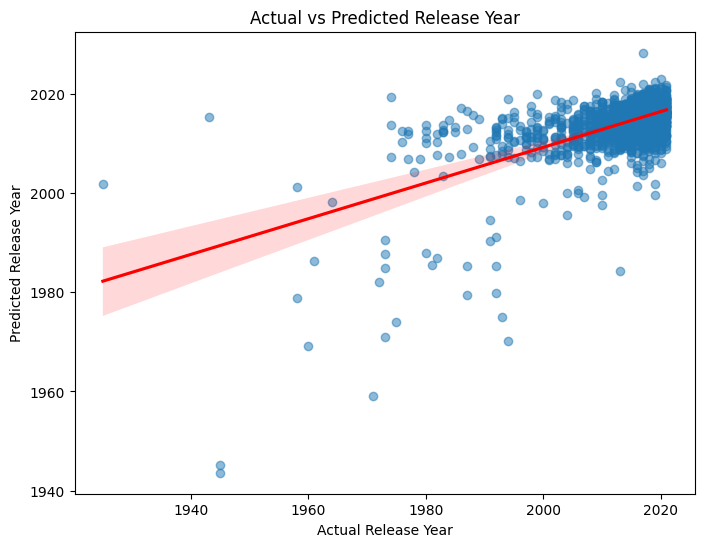

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.regplot(
    x=y_test,
    y=y_pred,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)

plt.xlabel("Actual Release Year")
plt.ylabel("Predicted Release Year")
plt.title("Actual vs Predicted Release Year")

plt.show()

Scatter plot shows the relationship between actual and predicted release years generated by the Linear Regression model. The model shows a positive trend indicating that it demonstrates better predictive performance for titles released in the year 2000-2020. However, it has a harder time capturing patterns from older titles due to limited number of older titles present in the dataset.

## 9. Results & Interpretation
- Summarize key findings
- Discuss insights generated from the data analysis and modeling
- Present the most informative visuals/tables with clear captions
- Relate results back to the research questions


### Regression
1. The Linear Regression model achieved an R² score of 0.349 indicating that approximately 34.9% of the variation in release year can be explained by the chosen variables.
2. This model also has a MAE of 4.27 meaning that predicted release years differ from actual release years by an average of 4 years.
3. It captures a better prediction from titles released in the year 2000-2020 compared to movies/TV shows released prior to 2000.

## 10. Conclusions & Limitations
- What did you learn?
- What are limitations and possible biases?
- What are logical next steps or improvements?


### Regression
- The limitiations I experienced is that the model has a more accurate prediction for titles released in the year 2000-2020. This is mainly because the dataset lacks titles that were released prior to 2000 which can affect the model's accuracy. The best step to improve my model is to remove the outliers which are movie/TV shows that were released prior to the 2000s. This can reduce my errors significantly and give me a better R² score.  

## References
- Any academic articles, blogs, or documentation used
- All references in APA format only
- Citation in text example: The field of natural language processing has become dominated by deep learning approaches (Young et al., [2018](https://doi.org/10.1109/MCI.2018.2840738)).
- Citation example in the list:
    - [Python Docs](https://docs.python.org/3/)
    - [Python Tutorial](https://docs.python.org/3/tutorial/index.html)



## Academic Integrity

- Work must be your own. If you use code snippets or ideas from references, cite them in the notebook.
- Do not include copyrighted data not permitted for redistribution.


## Plagiarism
It is fine to seek help from friends or from online resources when you do the assignment, However,
seeking help should not go overboard, to the point of getting (or even paying) someone to
complete the assignment partly or fully for you, copying from online resources without
understanding, or doing any means with the intention to cheat. 

For this assignment, plagiarism
means the following:
(a) Turning in a work that, from the examiner’s point of view, you do not sufficiently understand.
(b) Turning in someone else’s work (whether partly or fully) as your own.
(c) To use another’s work (whether partly or fully) without crediting the source.
(d) Any means of cheating.

**Plagiarism is a serious offence.**

**We will give ZERO (0) marks to students who plagiarize AND to students who intentionally or
unintentionally help other students to plagiarize by giving all or some of their code.**

## Final Self‑Checklist (before submitting)

* [ ] Rename your Jupyter Notebook file according to your group number
* [ ] All items in README section are filled up
* [ ] All group members' ID, name, and contribution fill-in.
* [ ] Dataset link is from a recognized source and publicly accessible
* [ ] YouTube link is accessible.
* [ ] Notebook runs end‑to‑end with no manual steps beyond placing data files
* [ ] Dataset loaded once only
* [ ] No absolute paths; only relative paths used
* [ ] All figures have titles/labels; text and tables are readable
* [ ] Methods and choices are explained and justified
* [ ] References properly cited
* [ ] Notebook is clear, professional, and run within reasonable runtime